# 01 - plot_hex_proximity()

This notebook __was used to create function plot_hex_proximity()__ based on existing hex_plot() function.
* In this notebook functions __square_bounds()__ and __observatory_plot_format()__ were also developed in order to use them in functions __plot_hex_proximity()__, __plot_hex_ndvi()__ and __plot_hex_temperature()__

## __Import libraries__

In [1]:
from pathlib import Path

current_path = Path().resolve()

for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break

print(project_root)

/home/jovyan/odc


In [2]:
import os
import sys

import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
# Import logo image
import matplotlib.image as mpimg
# Place logo image above plot
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Wrap title text inside plots
from textwrap import wrap

# Import cm, colors and colorbar to create colormap legends manually
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colorbar as colorbar

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

Path found


## __Config notebook__

In [3]:
res = 8
city = 'Aguascalientes'

## __Load data__

In [4]:
# Load data test
data_schema = 'prox_analysis'
data_table = f'proximityanalysis_v2_23_mzaageb_hex'
# Load city's hexs filtering for urban areas if required
query = f"SELECT * FROM {data_schema}.{data_table} WHERE \"city\" = '{city}\' AND \"res\" = '{res}\'"
data_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Show
print(data_gdf.crs)
print(data_gdf.shape)
data_gdf.head(2)

epsg:4326
(326, 69)


,hex_id,res,geometry,max_escuelas,max_preescolar,max_primaria,max_secundaria,max_servicios comunitarios,max_salud,max_guarderías,...,pobmas,p_0a5,p_6a11,p_12a17,p_18a24,p_25a59,p_60ymas,pcon_disc,dens_pob_ha,city
0,88498e3663fffff,8,"POLYGON ((-102.25507 21.87373, -102.25048 21.8...",19.555528,9.509851,10.855071,19.555528,15.093313,9.821487,10.963312,...,1848.5159,335.58023,333.89948,316.66147,421.74573,1794.56247,702.35020,329.46800,45.210681,Aguascalientes
1,88498e3455fffff,8,"POLYGON ((-102.25547 21.92880, -102.25087 21.9...",11.626070,10.694301,6.959306,11.626070,44.004748,9.532449,9.070579,...,6153.3457,1475.07596,1778.80790,1803.25476,1425.95680,5503.76543,471.98077,702.15735,144.291588,Aguascalientes


In [5]:
data_gdf.columns

Index(['hex_id', 'res', 'geometry', 'max_escuelas', 'max_preescolar',
       'max_primaria', 'max_secundaria', 'max_servicios comunitarios',
       'max_salud', 'max_guarderías', 'max_asistencia social', 'max_comercio',
       'max_alimentos', 'max_personal', 'max_farmacias', 'max_hogar',
       'max_complementarios', 'max_entretenimiento', 'max_social',
       'max_actividad física', 'max_cultural', 'escuelas_15min',
       'preescolar_15min', 'primaria_15min', 'secundaria_15min',
       'servicios comunitarios_15min', 'salud_15min', 'guarderías_15min',
       'asistencia social_15min', 'comercio_15min', 'alimentos_15min',
       'personal_15min', 'farmacias_15min', 'hogar_15min',
       'complementarios_15min', 'entretenimiento_15min', 'social_15min',
       'actividad física_15min', 'cultural_15min', 'idx_preescolar',
       'idx_primaria', 'idx_secundaria', 'idx_salud', 'idx_guarderías',
       'idx_asistencia social', 'idx_alimentos', 'idx_personal',
       'idx_farmacias', 'idx_h

In [6]:
# Download area of interest (aoi)
print('--- Downloading area of interest.')
metro_schema = 'metropolis'
metro_table = 'metro_gdf_2020'
query = f"SELECT * FROM {metro_schema}.{metro_table} WHERE \"city\" LIKE \'{city}\'"
mun_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Create area of interest from dissolved municipalities
mun_gdf.to_crs("EPSG:6372",inplace=True)
aoi = mun_gdf.buffer(5)
aoi_gdf = gpd.GeoDataFrame(geometry=aoi,crs="EPSG:6372").dissolve()
aoi_gdf.to_crs("EPSG:4326",inplace=True)

# Download Network (G, nodes, edges)
print('--- Downloading network.')
network_schema = 'osmnx'
nodes_table = 'nodes_osmnx_23_point'
edges_table = 'edges_speed_23_line'
G, nodes_gdf, edges_gdf = odc.graph_from_hippo(aoi, schema=network_schema, edges_folder=edges_table, nodes_folder=nodes_table)

# Show
print(edges_gdf.crs)
print(edges_gdf.shape)
edges_gdf.head(2)

--- Downloading area of interest.
--- Downloading network.
EPSG:4326
(128150, 19)


osmid  oneway                   name  \
u          v          key                                             
8414611560 1729024510 0    906116849   False  Boulevard Guadalupano   
           2304455693 0    906116850    True  Boulevard Guadalupano   

                             highway  length  \
u          v          key                      
8414611560 1729024510 0    secondary  53.013   
           2304455693 0    secondary  11.792   

                                                                    geometry  \
u          v          key                                                      
8414611560 1729024510 0    LINESTRING (-102.25354 21.91028, -102.25343 21...   
           2304455693 0    LINESTRING (-102.25354 21.91028, -102.25353 21...   

                           grade  grade_abs lanes bridge maxspeed     ref  \
u          v          key                                                   
8414611560 1729024510 0   -0.038      0.038     3   None     None  AGS 60   
           2304455693 0    0.000      0.000     3   None       40  AGS 60   

                          access junction service tunnel width  walkspeed  \
u          v          key                                                   
8414611560 1729024510 0     None     None    None   None  None    3.50186   
           2304455693 0     None     None    None   None  None    4.00000   

                           time_min  
u          v          key            
8414611560 1729024510 0    0.908311  
           2304455693 0    0.176880

## __Function development__

def square_bounds(ax, bounds_gdf, boundary_expansion=[0.05,0.05]):
    
    """
    This function takes an ax, a gdf and a list with two numeric values as input and modifies the ax's boundaries to set a squared bounds around bounds_gdf.
    These bounds can be expanded (symmetrically) using values from boundary_expansion.
    
    Arguments:
         ax (matplotlib.axes): ax to modify using ax.set_xlim() and  ax.set_ylim().
         bounds_gdf (geopandas.GeoDataFrame): GeoDataFrame with the geometry to be considered in the formation of the squared bounds.
         boundary_expansion (list,optional): List with two numeric values that represent percentages used to expand the squared-boundary plot symmetrically. 
                                             The first digit expands the x-axis and the second digit expands the y-axis.
                                             e.g. [0.05,0.10] would expand by 5% the horizontal bounds (2.5% to the left, 2.5% to the right)
                                             and by 10% the vertical bounds (5% to the bottom, 5% to the top). Defaults to [0.05,0.05].
     """
    
    # Calculate bounds_gdf's current bounding box
    minx, miny, maxx, maxy = bounds_gdf.total_bounds
    
    # Find bounding box's larger size and its proportions relative to the shorter side
    x_dist = abs(maxx-minx)
    y_dist = abs(maxy-miny)
    larger_side = max(x_dist,y_dist)
    smaller_side = min(x_dist,y_dist)
    #ax_proportions = larger_side/smaller_side #To be used in later function modifications

    # Turn into squared bounds by adding the difference between the larger_side and the smaller_side to the smaller_side
    size_diff = larger_side-smaller_side
    # If it is already a square, no need to calculate
    if size_diff == 0:
        square_minx = minx
        square_maxx = maxx
        square_miny = miny
        square_maxy = maxy
    else:
        # If x_dist is the larger, enlarge <y> side
        if x_dist>y_dist:
            square_minx = minx #<x> is larger size
            square_maxx = maxx #<x> is larger size
            square_miny = miny-(size_diff/2) #<y> is enlarged
            square_maxy = maxy+(size_diff/2) #<y> is enlarged
        # Else, y_dist is the larger, enlarge <x> side
        else:
            square_minx = minx-(size_diff/2) #<x> is enlarged
            square_maxx = maxx+(size_diff/2) #<x> is enlarged
            square_miny = miny #<y> is larger size
            square_maxy = maxy #<y> is larger size

    # Grow squared bound by specified values in boundary_expansion
    expanded_square_minx = square_minx - (larger_side*boundary_expansion[0])/2
    expanded_square_maxx = square_maxx + (larger_side*boundary_expansion[0])/2
    expanded_square_miny = square_miny - (larger_side*boundary_expansion[1])/2
    expanded_square_maxy = square_maxy + (larger_side*boundary_expansion[1])/2

    # Adjust ax limits accordingly
    ax.set_xlim(expanded_square_minx, expanded_square_maxx)
    ax.set_ylim(expanded_square_miny, expanded_square_maxy)

def observatory_plot_format(ax, plot_title, legend_title, legend_type, cmap_args=[], grid=False): 
    
    """
    This formats plots to the observatory's style:
    - Title on the top left corner of the plot.
    - Legend title in bold.
    - OdC's logo on the bottom right corner of the plot.

    IMPORTANT FUNCTIONALITY NOTE: Since matplotlib updates the layout size and proportions to the elements inserted onto the map, this function must be used as a final plot formatting, after plotting all map elements.
    
    Arguments:
         ax (matplotlib.axes): ax of interest.
         plot_title (str): Text to be set as main plot title.
         legend_title (str): Text to be set as legend title.
         legend_type (str): Must be either 'categorized' or 'colorbar'. Edits the legend according to its type.
         cmap_args (list, optional): Necessary if legend_type='colormap', must contain two values used to create the colorbar:
                                     - The first element must be the previously generated colormap (which can be obtained using plt.get_cmap(''))
                                     - The second element must be the previously generated norm colors (which can be obtained using colors.Normalize(vmin=vmin, vmax=vmax))
                                     Defaults to [].
         grid (bool, optional): If true turns on coordinates grid. Defaults to False.
     """
    ##########################################################################################
    # STEP 1: AX DIMENSIONS
    # Calculate current ax width, height and larger size (Relevant values used in title text wrapping, legent text sizing and image zoom calculation)
    fig = ax.figure
    fig.canvas.draw()  # Opens canvas in order to measure real size
    renderer = fig.canvas.get_renderer()
    bbox = ax.get_window_extent(renderer=renderer)
    ax_width_px = bbox.width
    ax_height_px = bbox.height
    ax_largersize_px = max(ax_width_px, ax_height_px)

    ##########################################################################################
    # STEP 2: MAIN TITLE FORMAT
    # MAIN TITLE FORMAT - Wrap title text
    # Calculate fontsize relative to ax width (Previously set fontsize = 12.5)
    fontsize = int(ax_largersize_px / 60)
    # Calculate aprox. number of characters that fit inside half the ax size (In order to wrap text when it reaches half the ax size)
    char_width_px = fontsize * 0.6  # Average size that a character occupies (in pixels)
    max_chars = int((ax_width_px * 0.40) / char_width_px)# (Chose 0.40 instead of 0.50 because the text doesn't start exactly over the left axis)
    # Wrap tittle
    wrapped_title = "\n".join(wrap(plot_title, width=max_chars))
    
    # MAIN TITLE FORMAT - Set title
    ax.text(0.03, 0.98, wrapped_title,
            fontsize=fontsize, 
            fontweight='bold',
            ha='left', va='top', # Text allignment
            transform=ax.transAxes, #ax.tramsAxes sets position relative to axes instead of coordinates
            #bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, boxstyle='round,pad=0.3') # Create semi-transparent box around text [Canceled]
           )
    
    ##########################################################################################
    # STEP 3: LEGEND TITLE FORMAT   
    # LEGEND TITLE FORMAT - Edit legend text size
    
    legend_fontsize = int(ax_width_px / 75)
    if legend_type == 'categorized':
        # Modify categorized legend, which is a matplotlib.legend.Legend and can be accessed using ax.get_legend()
        legend = ax.get_legend()
        legend.set_title(legend_title)
        legend.get_title().set_fontsize(legend_fontsize)
        legend.get_title().set_fontweight('bold')
        for text in legend.get_texts():
            text.set_fontsize(legend_fontsize)
    elif legend_type == 'colorbar':
        # Create a divider for the provided ax
        divider = odc.make_axes_locatable(ax)
        # Create an axe for the colorbar (The size will be the "size%" of the main ax, while there's a spacing (pad) between the main ax and the colorbar)
        cax = divider.append_axes("bottom", size="5%", pad=0.1)
        # Load previously created colorbar and norm
        cmap = cmap_args[0]
        norm = cmap_args[1]
        # Create colorbar manually
        cb = colorbar.ColorbarBase(ax=cax, cmap=cmap, norm=norm, orientation='horizontal')
        # Set colorbar label manually
        cb.set_label(legend_title, fontsize=legend_fontsize, fontweight='bold')
        cb.ax.tick_params(labelsize=legend_fontsize)
        
    ##########################################################################################
    # STEP 4: GRID FORMAT
    # Turn on grid if required
    if grid:
        ax.grid(color='grey', linestyle='--', linewidth=0.25) 

    ##########################################################################################
    # STEP 5: OBSERVATORY'S LOGO
    # Find current path to project
    from pathlib import Path
    current_path = Path().resolve()
    for parent in current_path.parents:
        if parent.name == "odc":
            project_root = parent
            break
    # Read image from dir starting in project_root
    img_dir = str(project_root)+'/data/external/odc_logo/LOGO OC_3.png'
    img = mpimg.imread(img_dir)
    # Calculate image zoom a) Get current image extent
    img_width_px = img.shape[1]
    # Calculate image zoom c) Calculate required zoom so that image occupies ~10% of larger ax size
    target_fraction = 0.05
    img_zoom = (ax_largersize_px * target_fraction) / img_width_px
    # Insert image on bottom right corner with specified zoom
    # (0,1) --> Upper left
    # (1,1) --> Upper right
    # (0,0) --> Lower left
    # (1,0) --> Lower right
    img_position = (0.98, 0.03)
    img_box = OffsetImage(img, zoom=img_zoom)
    ab = AnnotationBbox(img_box, img_position, frameon=False,
                        xycoords='axes fraction',  # Set coordinates relative to axis (e.g. (0,1))
                        box_alignment=img_position)  # Align image
    # Add image to ax
    ax.add_artist(ab)

def plot_hex_proximity(data_gdf, column, location_name, ax,
                       plot_osmnx_edges = (False, ''),
                       plot_boundary = (False, ''),
                       adjust_to = ('',[0.05,0.05]),
                       save_png = (False, '../output/figures/plot.png'),
                       png_transparency = False,
                       png_dpi = 300,
                       save_pdf = (False, '../output/figures/plot.pdf'),
                      ):
    """
    This function creates a plot designed to show proximity analysis values.
    
    Arguments:
         data_gdf (geopandas.GeoDataFrame): GeoDataFrame with the data to be plotted.
         column (str): Name of the column with the data to plot from the data_gdf GeoDataFrame.
         location_name (str): Name of the location (to be added on the plot title).
         ax (matplotlib.axes): ax to use in the plot.
    
    Keyword Arguments:
        plot_osmnx_edges (tuple, optional): Tuple containing boolean on position [0].
                                            If true, a gdf can be specified on position [1]. 
                                            The gdf must contain edges from Open Street Map with a column named 'highway' since the edges are shown according 'highway' values.
                                            Defaults to (False, '')
        plot_boundary (tuple, optional): Tuple containing boolean on position [0]. 
                                         If true, a gdf can be specified on position [1] and a boundary is ploted.
                                         Defaults to (False, '')
        adjust_to (tuple, optional): Argument to be passed to function square_bounds().
                                     Tupple containing string on position [0]. Passing 'boundary' adjustes zoom to boundary if provided, passing'edges' adjustes zoom to edges if provided, other strings adjustes zoom to data_gdf. 
                                     The image boundaries will be adjusted to form a square centered on the previously specified gdf.
                                     Position [1] must contain a list with two numbers. The first will expand the x axis and the second will expand the y axis.
                                     Example: ('boundary',[0.10,0.05]) sets the bounds of the image as a square around the boundary_gdf from plot_boundary[1] plus a 10% expansion on the x-axis and a 5% expansion on the y-axis.
        save_png (tuple, optional): Tupple containing boolean on position [0].
                                    If true, a string can be specified on position [1] indicating the directory and file name where the png is saved.
                                    Defaults to (False, '../output/figures/plot.png')
        png_transparency (bool): Saves the png with transparency or not. Defaults to False.
        png_dpi (int): Sets the resolution to be used to save the png. Defaults to 300.
        save_pdf (tuple, optional): Tupple containing boolean on position [0].
                                    If true, a string can be specified on position [1] indicating the directory and file name where the pdf is saved.
                                    Defaults to (False, '../output/figures/plot.pdf') 
    """

    
    # --------------- GENERAL PLOT STYLE
    data_linestyle = '-'
    data_linewidth = 0.35
    data_edgecolor = 'white'
    
    # --------------- FOR AMENITY AVAILABILITY (COUNT) DATA
    # (e.g. column 'cultural_15min', which indicates the average number of kindergardens on a 15 minutes walk by hex)
    if 'min' in column:
        # --- TITLE
        # Extract amenity name from column name
        amenity_name = column.split('_')[0]
        # Extract time used for availability calculation (normaly 15 minutes) from column name
        time_amount = column.split('_')[1]
        # Create plot title
        plot_title = f"Availability of {amenity_name} amenities on a {time_amount} walk in {location_name.capitalize()}."
        # --- LEGEND - COLOR BAR
        legend_type='colorbar'
        # Define cmap and normalization
        cmap = plt.get_cmap('viridis')
        vmin = data_gdf[column].min()
        vmax = data_gdf[column].max()
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        # --- PLOT
        # Plot proximity data USING LEGEND=FALSE (SETTING IT  MANUALLY)
        data_gdf.plot(ax=ax, column=column, cmap=cmap, legend=False,
                      linestyle=data_linestyle, linewidth=data_linewidth,
                      edgecolor=data_edgecolor, zorder=1)
        # Plot proximity data using the viridis color palette directly 
        # (Canceled since setting legend=True doesn't allow for label size and formatting modification. Would require to divide ax previously to get cax)
        #data_gdf.plot(ax=ax,column=column,cmap='viridis',legend=True,cax=cax,legend_kwds={'label':f"Column: {column}.",'orientation': "horizontal"},linestyle=data_linestyle,linewidth=data_linewidth,edgecolor=data_edgecolor,zorder=1)         
    
    # --------------- FOR PROXIMITY INDEX (IDX) DATA
    # (e.g. column 'idx_preescolar', which indicates the proximity index (using a sigmodial function) for kindergardens)
    elif 'idx' in column:
        # --- TITLE
        # Set plot title
        if column == 'idx_sum': #All-amenities index
            plot_title = f"Proximity index (Sigmodial) for all amenities in {location_name.capitalize()}."
        else: # Index to specific amenity
            # Extract amenity name from column name
            amenity_name = column.split('_')[1]
            plot_title = f"Proximity index (Sigmodial) for {amenity_name} amenities in {location_name.capitalize()}."
        # --- LEGEND - COLOR BAR
        legend_type='colorbar'
        # Define cmap and normalization
        cmap = plt.get_cmap('magma')
        vmin = data_gdf[column].min()
        vmax = data_gdf[column].max()
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        # --- PLOT
        # Plot proximity data USING LEGEND=FALSE (SETTING IT  MANUALLY)
        data_gdf.plot(ax=ax, column=column, cmap=cmap, legend=False,
                      linestyle=data_linestyle, linewidth=data_linewidth,
                      edgecolor=data_edgecolor, zorder=1)
        # Plot proximity data using the magma color palette directly
        # (Canceled since setting legend=True doesn't allow for label size and formatting modification. Would require to divide ax previously to get cax)
        #data_gdf.plot(ax=ax,column=column,cmap='magma',legend=True,cax=cax,legend_kwds={'label':f"Column: {column}.",'orientation': "horizontal"},linestyle=data_linestyle,linewidth=data_linewidth,edgecolor=data_edgecolor,zorder=1)
    
    # --------------- FOR PROXIMITY (TIME) DATA
    # (e.g. columns 'max_preescolar' or 'median_time', which indicates average time (minutes) data and is categorized in time bins)
    elif ('max' in column) or ('time' in column):
        # --- TITLE
        # Set plot title
        if 'time' in column: #Time to all amenities
            # Extract statistical selected (Can be mean_time, median_time or max_time) from column name
            statistical = column.split('_')[0]
            plot_title = f"Proximity analysis ({statistical} time) to all amenities in {location_name.capitalize()}."
        else: # Time to specific amenity
            # Extract amenity name from column name
            amenity_name = column.split('_')[1]
            plot_title = f"Time to {amenity_name} amenities in {location_name.capitalize()}."
        # --- LEGEND - CATEGORIZED
        legend_type='categorized'
        # Categorize time data in time bins
        data_gdf.loc[data_gdf[column]>=60 , f'{column}_cat'] = '60 or more minutes'
        data_gdf.loc[(data_gdf[column]>=45 )&
                     (data_gdf[column]<60), f'{column}_cat'] = '45 minutes to 60 minutes'
        data_gdf.loc[(data_gdf[column]>=30)&
                     (data_gdf[column]<45), f'{column}_cat'] = '30 minutes to 45 minutes'
        data_gdf.loc[(data_gdf[column]>=15)&
                     (data_gdf[column]<30), f'{column}_cat'] = '15 minutes to 30 minutes'
        data_gdf.loc[(data_gdf[column]<15), f'{column}_cat'] = '15 minutes or less'
        # Order data
        categories = ['15 minutes or less','15 minutes to 30 minutes','30 minutes to 45 minutes','45 minutes to 60 minutes','60 or more minutes']
        data_gdf[f'{column}_cat'] = pd.Categorical(data_gdf[f'{column}_cat'], categories=categories, ordered=True)
        # --- PLOT
        # Plot proximity data using the viridis color palette reversed
        data_gdf.plot(ax=ax,column=f'{column}_cat',cmap='viridis_r',legend=True,legend_kwds={'loc':'lower left'},linestyle=data_linestyle,linewidth=data_linewidth,edgecolor=data_edgecolor,zorder=1)

    # --------------- OPTIONAL COMPLEMENTS (Area of interest boundary and streets)
    # Plot boundary if available
    if plot_boundary[0]:
        boundary_gdf = plot_boundary[1].copy()
        boundary_gdf.boundary.plot(ax=ax,color='#bebebe',linestyle='--',linewidth=0.75,zorder=2)
    # Plot edges if available
    if plot_osmnx_edges[0]:
        edges_gdf = plot_osmnx_edges[1].copy()
        # Plot edges (Main)
        edges_shown_a = ['trunk','trunk_link','motorway','motorway_link']
        edges_gdf_main = edges_gdf[edges_gdf['highway'].isin(edges_shown_a)].copy()
        if len(edges_gdf_main) > 0:
            edges_main=True
            edges_gdf_main.plot(ax=ax,color='#000000',alpha=0.5,linewidth=1.0,zorder=3)
        # Plot edges (Primary and secondary)
        edges_shown_b = ['primary','primary_link']#,'secondary','secondary_link']
        edges_gdf_primary = edges_gdf[edges_gdf['highway'].isin(edges_shown_b)].copy()
        if len(edges_gdf_primary) > 0:
            edges_primary=True
            edges_gdf_primary.plot(ax=ax,color='#000000',alpha=0.5,linewidth=0.50,zorder=3)
    
	# --------------- FINAL PLOT FORMAT
    # FORMAT - AX SIZE - Edit ax size to fit specified gdf exclusively using square_bounds() function
    # If specified 'boundary' and boundary_gdf available
    if (adjust_to[0] == 'boundary') and (plot_boundary[0]):
        odc.square_bounds(ax, boundary_gdf, adjust_to[1])
    # Elif specified 'edges' and edges_gdf available
    elif (adjust_to[0] == 'edges') and (plot_osmnx_edges[0]):
        if edges_main and edges_primary:
            odc.square_bounds(ax, pd.concat([edges_gdf_main,edges_gdf_primary]), adjust_to[1])
        elif edges_main:
            odc.square_bounds(ax, edges_gdf_main, adjust_to[1])
        elif edges_primary:
            odc.square_bounds(ax, edges_gdf_primary, adjust_to[1])
        else:
            odc.square_bounds(ax, data_gdf, adjust_to[1])
    # Else, if specified something else, use data_gdf
    else:
        odc.square_bounds(ax, data_gdf, adjust_to[1])

    # FORMAT - OBSERVATORY'S PLOT FORMAT - Controls positioning, style and sizing for main title, legend, grid and logo.
    if legend_type=='colorbar':
        odc.observatory_plot_format(ax=ax,
                                    plot_title=plot_title,
                                    legend_title = f'Column: {column}.',
                                    legend_type=legend_type,
                                    cmap_args=[cmap,norm],
                                    grid=False
                                   )
    else:
        odc.observatory_plot_format(ax=ax,
                                    plot_title=plot_title,
                                    legend_title = f'Column: {column}.',
                                    legend_type=legend_type,
                                    cmap_args=[],
                                    grid=False
                                   )
    
    # --------------- SAVING CONFIGURATIONS
    # Save or show plot
    if save_png[0]:
        plt.savefig(save_png[1],dpi=png_dpi,transparent=png_transparency)
    if save_pdf[0]:
        plt.savefig(save_pdf[1])

## __Function testing__

### __Function testing__ - Function with no other kwargs

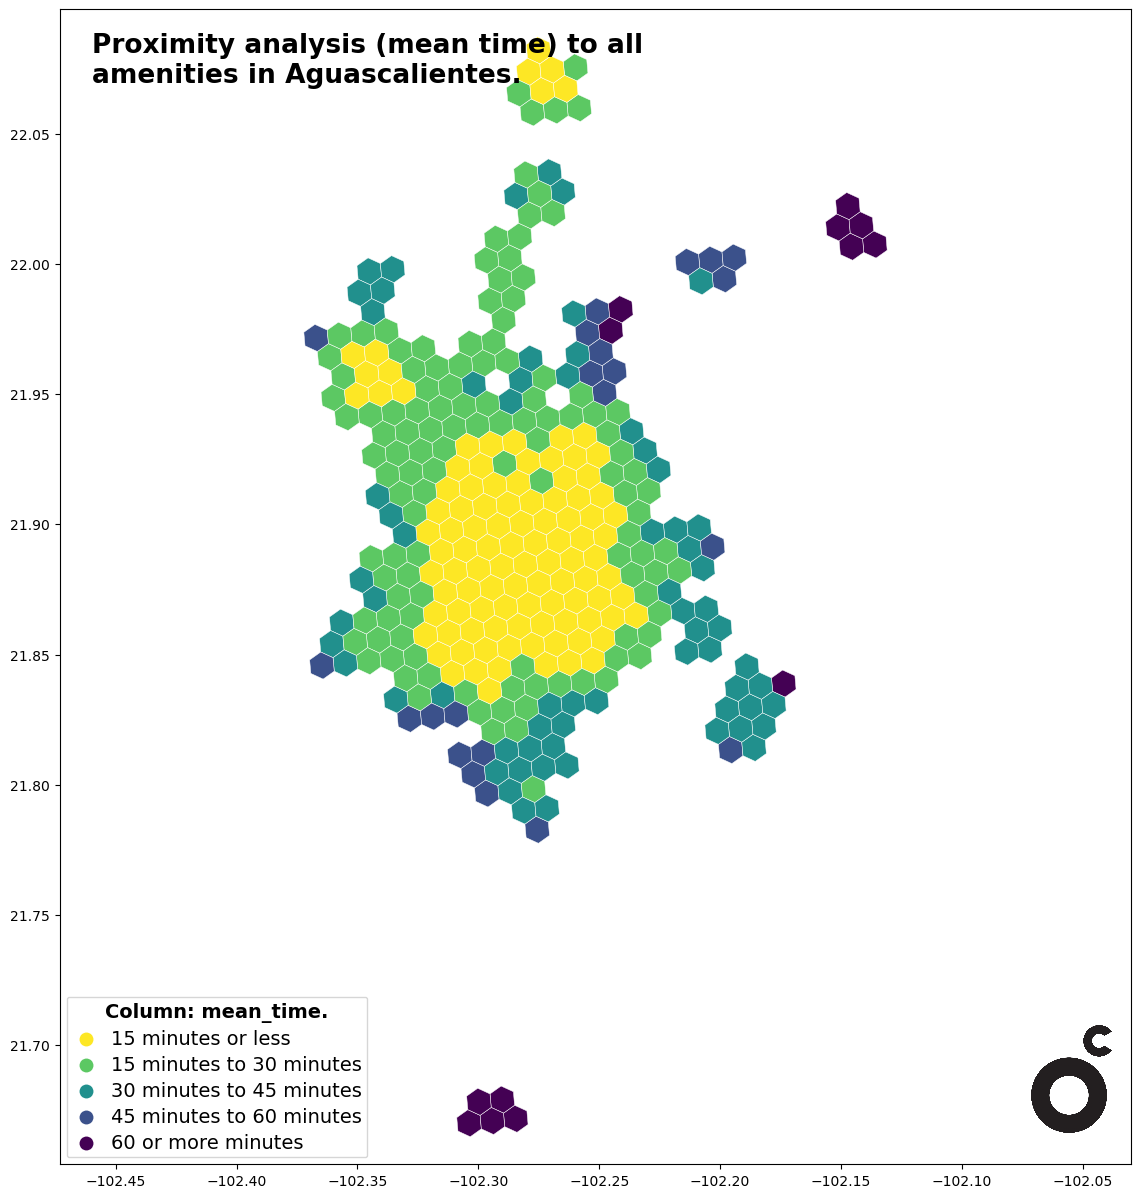

In [7]:
fig,ax = plt.subplots(figsize=(30,15))

# Classic proximity analysis
odc.plot_hex_proximity(data_gdf = data_gdf,
                       location_name = city,
                       ax=ax
                      )

### __Function testing__ - Function with boundary and streets showing plot size and proportions modifications

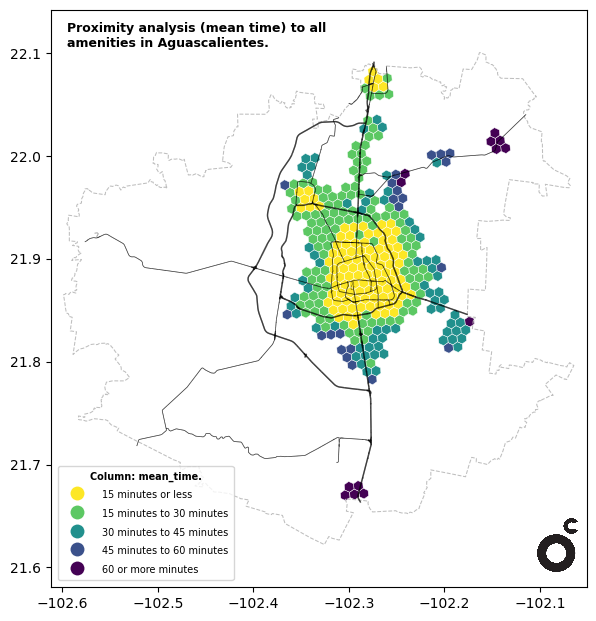

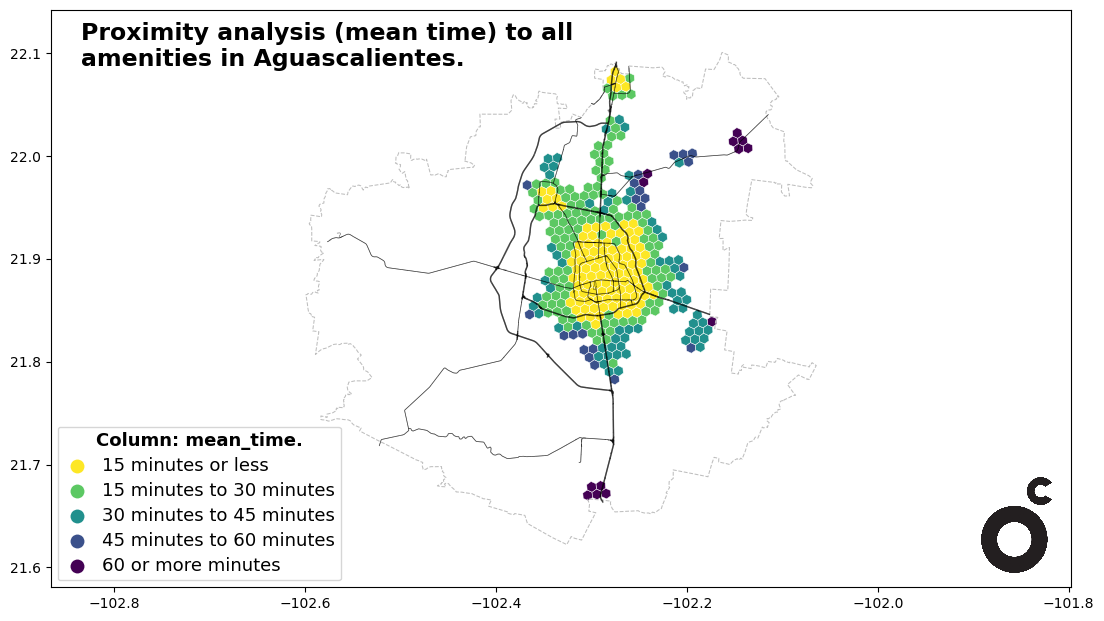

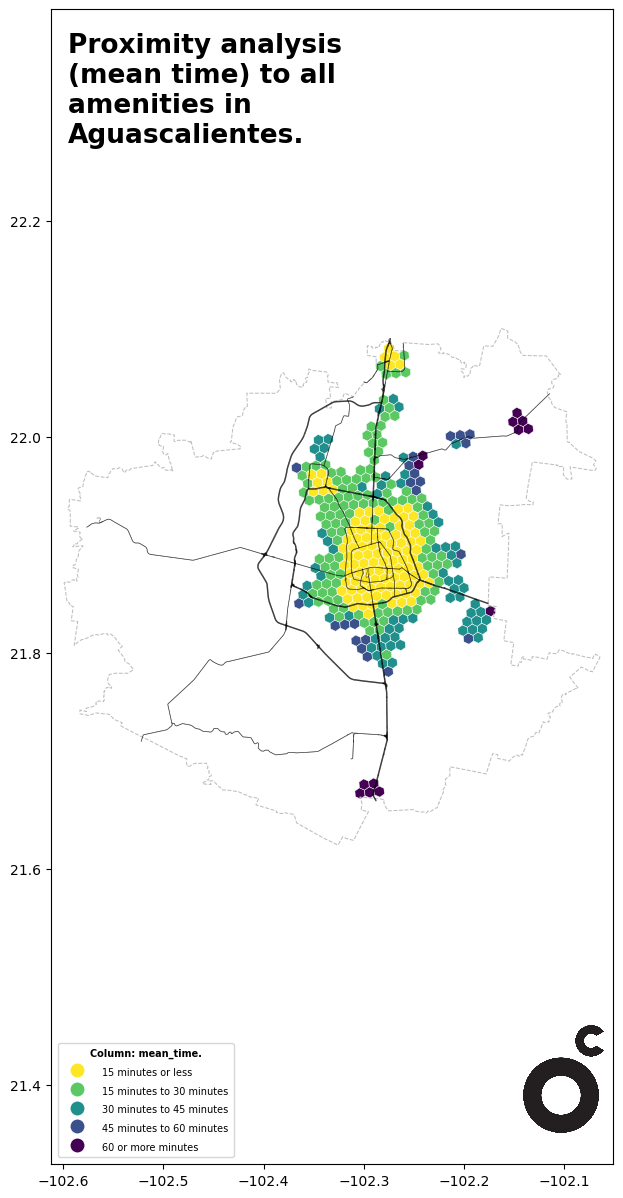

In [10]:
kwargs_dict = {"plot_osmnx_edges": (True, edges_gdf),
               "plot_boundary": (True, aoi_gdf),
              }

# Time plot (mean_time) on a square plot
fig,ax = plt.subplots(figsize=(7.5,7.5))
odc.plot_hex_proximity(data_gdf = data_gdf,
                       location_name = city,
                       ax=ax,
                       adjust_to = ('boundary',[0.05,0.05]), #Kwarg creating squared plot
                       **kwargs_dict
                      )

fig,ax = plt.subplots(figsize=(15,7.5))
# Time plot (mean_time) on a rectangular plot (horizontal)
odc.plot_hex_proximity(data_gdf = data_gdf,
                       location_name = city,
                       ax=ax,
                       adjust_to = ('boundary',[1,0.05]), #Kwarg creating rectangular horizontal plot
                       **kwargs_dict
                      )

fig,ax = plt.subplots(figsize=(7.5,15))
# Time plot (mean_time) on a rectangular plot (vertical)
odc.plot_hex_proximity(data_gdf = data_gdf,
                       location_name = city,
                       ax=ax,
                       adjust_to = ('boundary',[0.05,1]), #Kwarg creating rectangular vertical plot
                       **kwargs_dict
                      )

### __Function testing__ - Function with data other than mean proximity analysis

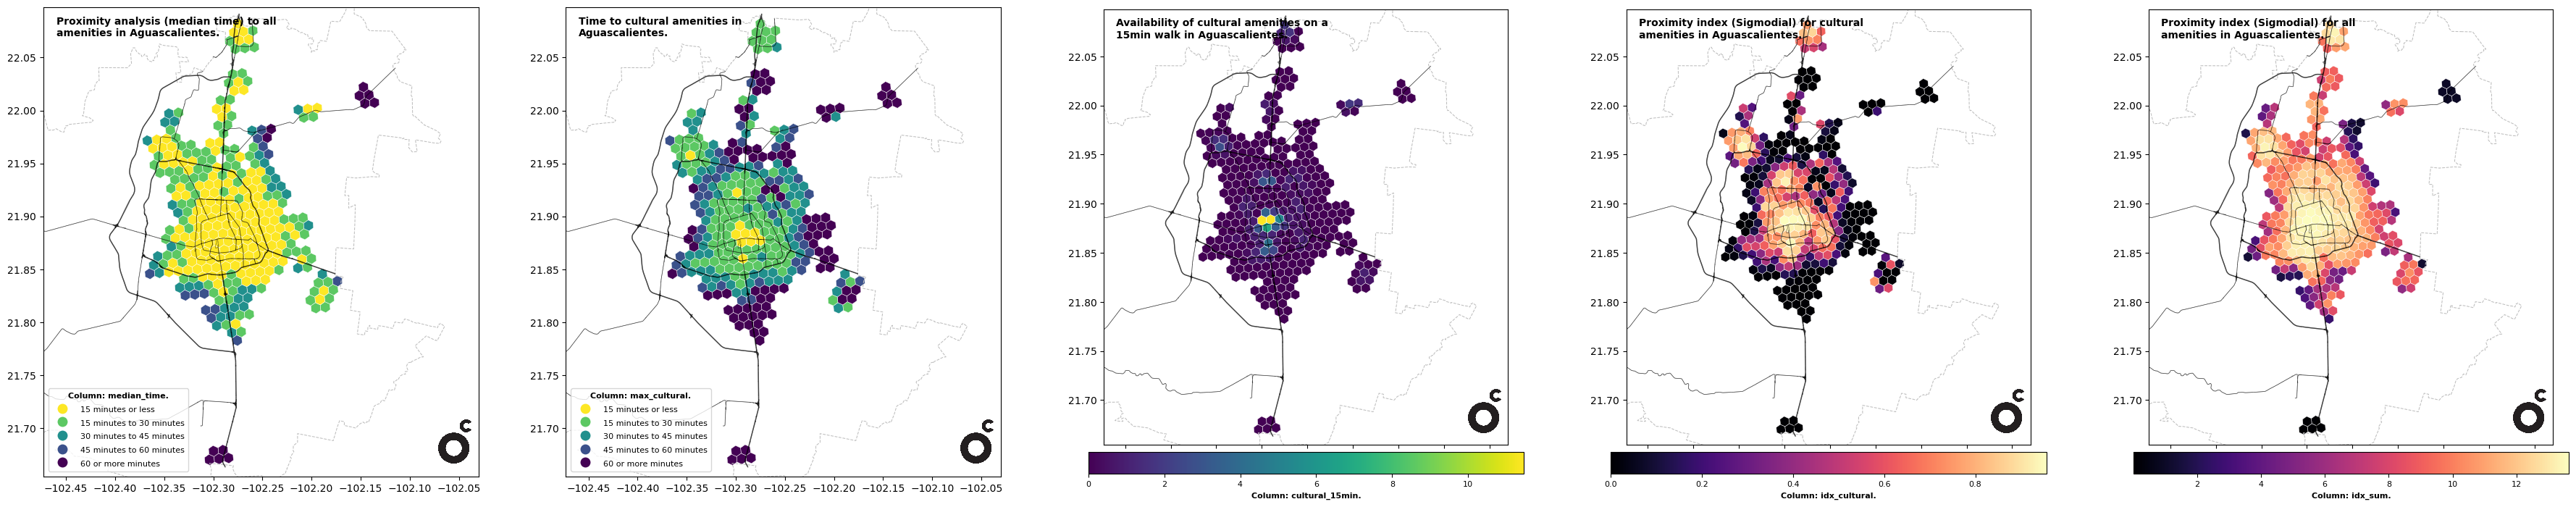

In [11]:
kwargs_dict = {"plot_osmnx_edges": (True, edges_gdf),
               "plot_boundary": (True, aoi_gdf),
              }

fig,axs = plt.subplots(1,5,figsize=(45,15))

# ----- PROXIMITY MEASURED IN TIME -----
# Time plot (median_time)
odc.plot_hex_proximity(data_gdf = data_gdf,
                   column = 'median_time',
                   location_name = city,
                   ax=axs[0],
                   **kwargs_dict
                  )
# Time plot (max_cultural)
odc.plot_hex_proximity(data_gdf = data_gdf,
                   column = 'max_cultural',
                   location_name = city,
                   ax=axs[1],
                   **kwargs_dict
                  )

# ----- AMENITIES COUNT -----
# Count plot (cultural_15min)
odc.plot_hex_proximity(data_gdf = data_gdf,
                   column = 'cultural_15min',
                   location_name = city,
                   ax=axs[2],
                   **kwargs_dict
                  )

# ----- SIGMODIAL INDEX -----
# Index plot (idx_cultural)
odc.plot_hex_proximity(data_gdf = data_gdf,
                   column = 'idx_cultural',
                   location_name = city,
                   ax=axs[3],
                   **kwargs_dict
                  )
# Index plot (idx_sum)
odc.plot_hex_proximity(data_gdf = data_gdf,
                   column = 'idx_sum',
                   location_name = city,
                   ax=axs[4],
                   **kwargs_dict
                  )